Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load data 

In [2]:
ratings = pd.read_csv('../data/ratings.csv')
movies = pd.read_csv('../data/movies.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


How many unique user and movies are available ?

In [3]:
ratings['userId'].nunique(), ratings['movieId'].nunique()

(610, 9724)

Total ratings 

In [4]:
len(ratings)

100836

Rating distrubution :
  Do users give mostly high ratings ?
  Is the dataset biased ?

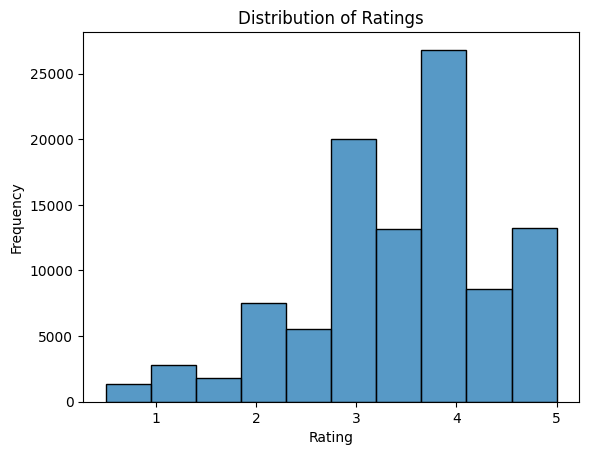

In [5]:
sns.histplot(ratings['rating'], bins=10)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency') 
plt.show()

Ratings per movie :
Check how the ratings are spread across movies 

Note: Movies with few movies are hard to recommend 

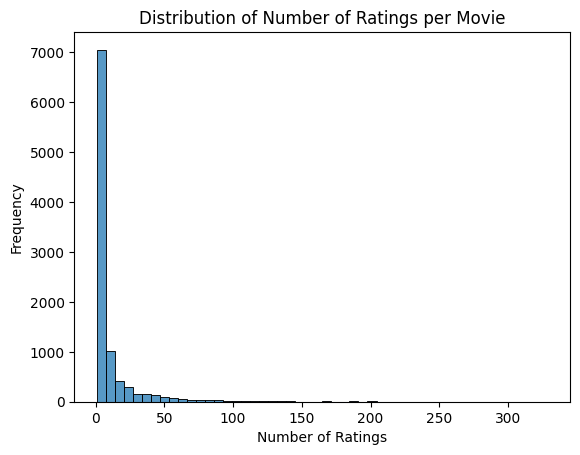

In [6]:
ratings_per_movie = ratings.groupby('movieId')['rating'].count()

sns.histplot(ratings_per_movie, bins=50)
plt.title('Distribution of Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')     
plt.show()

Combine movie names with ratings 

In [7]:
data=pd.merge(ratings, movies, on='movieId')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Most popular movies 

In [9]:
popular_movies = data.groupby('title')['rating'].count().sort_values(ascending=False)

popular_movies.head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

Frist recommendation : 
    Recommend most popular movies 
    Baseline model